<a href="https://colab.research.google.com/github/TanyaTejaswi/Walmart-Store-Clustering/blob/main/Walmart_Store_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

print("Train:", train.shape)
print("Features:", features.shape)
print("Stores:", stores.shape)

Train: (421570, 5)
Features: (8190, 12)
Stores: (45, 3)


In [3]:
print("TRAIN")
display(train.head())

print("\nFEATURES")
display(features.head())

print("\nSTORES")
display(stores.head())

TRAIN


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False



FEATURES


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False



STORES


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [4]:
print("TRAIN MISSING VALUES")
print(train.isnull().sum())

print("\nFEATURES MISSING VALUES")
print(features.isnull().sum())

print("\nSTORES MISSING VALUES")
print(stores.isnull().sum())

TRAIN MISSING VALUES
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

FEATURES MISSING VALUES
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

STORES MISSING VALUES
Store    0
Type     0
Size     0
dtype: int64


In [5]:
print("TRAIN DATA TYPES")
print(train.dtypes)

print("\nFEATURES DATA TYPES")
print(features.dtypes)

print("\nSTORES DATA TYPES")
print(stores.dtypes)

print("\nDUPLICATES")
print("Train:", train.duplicated().sum())
print("Features:", features.duplicated().sum())
print("Stores:", stores.duplicated().sum())

TRAIN DATA TYPES
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

FEATURES DATA TYPES
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

STORES DATA TYPES
Store     int64
Type     object
Size      int64
dtype: object

DUPLICATES
Train: 0
Features: 0
Stores: 0


In [6]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

print(train["Date"].dtype)
print(features["Date"].dtype)

datetime64[ns]
datetime64[ns]


In [7]:
merged = pd.merge(
    train,
    features,
    on=["Store", "Date"],
    how="left"
)

print("Merged shape:", merged.shape)
print(merged.head())

Merged shape: (421570, 15)
   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50        False        42.31       2.572   
1      1     1 2010-02-12      46039.49         True        38.51       2.548   
2      1     1 2010-02-19      41595.55        False        39.93       2.514   
3      1     1 2010-02-26      19403.54        False        46.63       2.561   
4      1     1 2010-03-05      21827.90        False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment  IsHoliday_y  
0         8.106       

In [8]:
merged = merged.drop(columns=["IsHoliday_y"])
merged = merged.rename(columns={"IsHoliday_x": "IsHoliday"})

print(merged.columns.tolist())
print("Shape:", merged.shape)

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']
Shape: (421570, 14)


In [9]:
merged = pd.merge(
    merged,
    stores,
    on="Store",
    how="left"
)

print("Shape:", merged.shape)
print(merged.head())

Shape: (421570, 16)
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   
3      1     1 2010-02-26      19403.54      False        46.63       2.561   
4      1     1 2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         

In [10]:
print("Number of stores:", merged["Store"].nunique())
print("Number of departments:", merged["Dept"].nunique())
print("Date range:", merged["Date"].min(), "to", merged["Date"].max())

print("\nStore types:")
print(merged["Type"].value_counts())

Number of stores: 45
Number of departments: 81
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

Store types:
Type
A    215478
B    163495
C     42597
Name: count, dtype: int64


In [11]:
print("Missing CPI rows:", merged["CPI"].isna().sum())
print("Missing Unemployment rows:", merged["Unemployment"].isna().sum())

print("\nDates with missing CPI:")
print(merged.loc[merged["CPI"].isna(), "Date"].unique())

print("\nDates with missing Unemployment:")
print(merged.loc[merged["Unemployment"].isna(), "Date"].unique())

Missing CPI rows: 0
Missing Unemployment rows: 0

Dates with missing CPI:
<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]

Dates with missing Unemployment:
<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]


In [12]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

merged[markdown_cols] = merged[markdown_cols].fillna(0)

print("Remaining missing values in Markdown columns:")
print(merged[markdown_cols].isnull().sum())

Remaining missing values in Markdown columns:
MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


In [13]:
print("Weekly Sales Statistics:")
print(merged["Weekly_Sales"].describe())

Weekly Sales Statistics:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


In [14]:
store_features = merged.groupby("Store").agg(
    Avg_Weekly_Sales=("Weekly_Sales", "mean"),
    Sales_Std=("Weekly_Sales", "std"),
    Total_Sales=("Weekly_Sales", "sum"),
    Min_Sales=("Weekly_Sales", "min"),
    Max_Sales=("Weekly_Sales", "max"),
    Num_Departments=("Dept", "nunique")
).reset_index()

print("Shape:", store_features.shape)
display(store_features.head())

Shape: (45, 7)


,Store,Avg_Weekly_Sales,Sales_Std,Total_Sales,Min_Sales,Max_Sales,Num_Departments
0,1,21710.543621,27748.945511,2.224028e+08,-863.00,203670.47,77
1,2,26898.070031,33077.612059,2.753824e+08,-1098.00,285353.53,78
2,3,6373.033983,14251.034807,5.758674e+07,-1008.96,155897.94,72
3,4,29161.210415,34583.677814,2.995440e+08,-898.00,385051.04,78
4,5,5053.415813,8068.221050,4.547569e+07,-101.26,93517.72,72


In [15]:
store_info = stores.copy()

store_features = pd.merge(
    store_features,
    store_info,
    on="Store",
    how="left"
)

print("Shape:", store_features.shape)
display(store_features.head())

Shape: (45, 9)


,Store,Avg_Weekly_Sales,Sales_Std,Total_Sales,Min_Sales,Max_Sales,Num_Departments,Type,Size
0,1,21710.543621,27748.945511,2.224028e+08,-863.00,203670.47,77,A,151315
1,2,26898.070031,33077.612059,2.753824e+08,-1098.00,285353.53,78,A,202307
2,3,6373.033983,14251.034807,5.758674e+07,-1008.96,155897.94,72,B,37392
3,4,29161.210415,34583.677814,2.995440e+08,-898.00,385051.04,78,A,205863
4,5,5053.415813,8068.221050,4.547569e+07,-101.26,93517.72,72,B,34875


In [16]:
economic_features = merged.groupby("Store")[[
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]].mean().reset_index()

economic_features = economic_features.rename(columns={
    "Temperature": "Avg_Temperature",
    "Fuel_Price": "Avg_Fuel_Price",
    "CPI": "Avg_CPI",
    "Unemployment": "Avg_Unemployment"
})

store_features = store_features.merge(
    economic_features,
    on="Store",
    how="left"
)

print("Shape:", store_features.shape)

Shape: (45, 13)


In [17]:
markdown_features = merged.groupby("Store").agg(
    Avg_MarkDown1=("MarkDown1", "mean"),
    Avg_MarkDown2=("MarkDown2", "mean"),
    Avg_MarkDown3=("MarkDown3", "mean"),
    Avg_MarkDown4=("MarkDown4", "mean"),
    Avg_MarkDown5=("MarkDown5", "mean")
).reset_index()

store_features = store_features.merge(
    markdown_features,
    on="Store",
    how="left"
)

print("Shape:", store_features.shape)

Shape: (45, 18)


In [18]:
holiday_features = merged.groupby(
    ["Store", "IsHoliday"]
)["Weekly_Sales"].mean().unstack(fill_value=0).reset_index()

holiday_features = holiday_features.rename(columns={
    False: "Avg_NonHoliday_Sales",
    True: "Avg_Holiday_Sales"
})

holiday_features["Holiday_Sales_Ratio"] = (
    holiday_features["Avg_Holiday_Sales"] /
    holiday_features["Avg_NonHoliday_Sales"]
)

store_features = store_features.merge(
    holiday_features,
    on="Store",
    how="left"
)

print("Shape:", store_features.shape)
display(store_features.head())

Shape: (45, 21)


,Store,Avg_Weekly_Sales,Sales_Std,Total_Sales,Min_Sales,Max_Sales,Num_Departments,Type,Size,Avg_Temperature,...,Avg_CPI,Avg_Unemployment,Avg_MarkDown1,Avg_MarkDown2,Avg_MarkDown3,Avg_MarkDown4,Avg_MarkDown5,Avg_NonHoliday_Sales,Avg_Holiday_Sales,Holiday_Sales_Ratio
0,1,21710.543621,27748.945511,2.224028e+08,-863.00,203670.47,77,A,151315,68.224463,...,215.995525,7.610918,2886.877467,873.291894,436.207316,1340.570529,1794.852645,21609.634733,23039.386667,1.066163
1,2,26898.070031,33077.612059,2.753824e+08,-1098.00,285353.53,78,A,202307,68.105435,...,215.651869,7.623279,3815.003642,1571.495877,608.139075,1702.223652,2342.706654,26753.864227,28798.710526,1.076432
2,3,6373.033983,14251.034807,5.758674e+07,-1008.96,155897.94,72,B,37392,71.298627,...,219.402843,7.175602,1104.843804,294.276057,288.622421,317.644571,455.513285,6332.098604,6916.446288,1.092283
3,4,29161.210415,34583.677814,2.995440e+08,-898.00,385051.04,78,A,205863,62.176867,...,128.680070,5.965849,3352.829782,1381.076520,686.803667,1839.689313,2438.110453,29032.260570,30854.231417,1.062757
4,5,5053.415813,8068.221050,4.547569e+07,-101.26,93517.72,72,B,34875,69.203619,...,216.576516,6.296549,1079.143440,300.162839,235.176435,395.045179,915.256248,5010.249172,5617.212609,1.121144


In [19]:
numeric_features = store_features.select_dtypes(include=["number"])

correlation = numeric_features.corr()

display(correlation.round(2))

,Store,Avg_Weekly_Sales,Sales_Std,Total_Sales,Min_Sales,Max_Sales,Num_Departments,Size,Avg_Temperature,Avg_Fuel_Price,Avg_CPI,Avg_Unemployment,Avg_MarkDown1,Avg_MarkDown2,Avg_MarkDown3,Avg_MarkDown4,Avg_MarkDown5,Avg_NonHoliday_Sales,Avg_Holiday_Sales,Holiday_Sales_Ratio
Store,1.00,-0.30,-0.25,-0.35,-0.02,-0.24,-0.51,-0.24,-0.04,0.20,-0.21,0.24,-0.35,-0.38,-0.46,-0.32,-0.11,-0.30,-0.32,-0.50
Avg_Weekly_Sales,-0.30,1.00,0.97,0.99,-0.12,0.68,0.55,0.81,-0.02,0.05,-0.06,-0.09,0.75,0.85,0.80,0.79,0.61,1.00,1.00,0.07
Sales_Std,-0.25,0.97,1.00,0.95,-0.10,0.62,0.42,0.73,0.04,0.04,-0.04,-0.06,0.66,0.76,0.71,0.70,0.55,0.97,0.97,-0.01
Total_Sales,-0.35,0.99,0.95,1.00,-0.13,0.70,0.64,0.85,-0.08,0.05,-0.08,-0.11,0.80,0.89,0.84,0.84,0.62,0.99,0.99,0.15
Min_Sales,-0.02,-0.12,-0.10,-0.13,1.00,-0.38,-0.17,-0.15,-0.07,-0.16,0.11,-0.34,-0.28,-0.08,-0.12,-0.24,-0.13,-0.11,-0.15,-0.39
Max_Sales,-0.24,0.68,0.62,0.70,-0.38,1.00,0.58,0.52,-0.11,0.32,-0.26,0.11,0.78,0.74,0.80,0.76,0.48,0.68,0.71,0.52
Num_Departments,-0.51,0.55,0.42,0.64,-0.17,0.58,1.00,0.77,-0.45,0.03,-0.08,-0.18,0.84,0.78,0.80,0.79,0.50,0.55,0.58,0.62
Size,-0.24,0.81,0.73,0.85,-0.15,0.52,0.77,1.00,-0.18,0.01,-0.01,-0.09,0.83,0.81,0.73,0.82,0.67,0.81,0.81,0.20
Avg_Temperature,-0.04,-0.02,0.04,-0.08,-0.07,-0.11,-0.45,-0.18,1.00,-0.08,0.32,0.27,-0.27,-0.27,-0.29,-0.24,0.07,-0.02,-0.03,-0.23
Avg_Fuel_Price,0.20,0.05,0.04,0.05,-0.16,0.32,0.03,0.01,-0.08,1.00,-0.72,0.47,0.19,0.17,0.16,0.21,-0.10,0.05,0.07,0.13


In [20]:
store_features["Avg_Total_MarkDown"] = (
    store_features["Avg_MarkDown1"] +
    store_features["Avg_MarkDown2"] +
    store_features["Avg_MarkDown3"] +
    store_features["Avg_MarkDown4"] +
    store_features["Avg_MarkDown5"]
)

print(store_features[[
    "Store",
    "Avg_Total_MarkDown"
]].head())

   Store  Avg_Total_MarkDown
0      1         7331.799851
1      2        10039.568900
2      3         2460.900137
3      4         9698.509734
4      5         2924.784143


In [21]:
cluster_features = store_features[[
    "Store",
    "Avg_Weekly_Sales",
    "Sales_Std",
    "Size",
    "Num_Departments",
    "Avg_Total_MarkDown",
    "Avg_Temperature",
    "Avg_Fuel_Price",
    "Avg_CPI",
    "Avg_Unemployment",
    "Holiday_Sales_Ratio",
    "Type"
]].copy()

print("Shape:", cluster_features.shape)
display(cluster_features.head())

Shape: (45, 12)


,Store,Avg_Weekly_Sales,Sales_Std,Size,Num_Departments,Avg_Total_MarkDown,Avg_Temperature,Avg_Fuel_Price,Avg_CPI,Avg_Unemployment,Holiday_Sales_Ratio,Type
0,1,21710.543621,27748.945511,151315,77,7331.799851,68.224463,3.218811,215.995525,7.610918,1.066163,A
1,2,26898.070031,33077.612059,202307,78,10039.568900,68.105435,3.219898,215.651869,7.623279,1.076432,A
2,3,6373.033983,14251.034807,37392,72,2460.900137,71.298627,3.219112,219.402843,7.175602,1.092283,B
3,4,29161.210415,34583.677814,205863,78,9698.509734,62.176867,3.216237,128.680070,5.965849,1.062757,A
4,5,5053.415813,8068.221050,34875,72,2924.784143,69.203619,3.220912,216.576516,6.296549,1.121144,B


In [22]:
cluster_encoded = pd.get_dummies(
    cluster_features,
    columns=["Type"],
    dtype=int
)

print("Shape:", cluster_encoded.shape)
display(cluster_encoded.head())

Shape: (45, 14)


,Store,Avg_Weekly_Sales,Sales_Std,Size,Num_Departments,Avg_Total_MarkDown,Avg_Temperature,Avg_Fuel_Price,Avg_CPI,Avg_Unemployment,Holiday_Sales_Ratio,Type_A,Type_B,Type_C
0,1,21710.543621,27748.945511,151315,77,7331.799851,68.224463,3.218811,215.995525,7.610918,1.066163,1,0,0
1,2,26898.070031,33077.612059,202307,78,10039.568900,68.105435,3.219898,215.651869,7.623279,1.076432,1,0,0
2,3,6373.033983,14251.034807,37392,72,2460.900137,71.298627,3.219112,219.402843,7.175602,1.092283,0,1,0
3,4,29161.210415,34583.677814,205863,78,9698.509734,62.176867,3.216237,128.680070,5.965849,1.062757,1,0,0
4,5,5053.415813,8068.221050,34875,72,2924.784143,69.203619,3.220912,216.576516,6.296549,1.121144,0,1,0


In [23]:
store_ids = cluster_encoded["Store"]

X = cluster_encoded.drop(columns=["Store"])

print("Clustering features shape:", X.shape)
print(X.columns.tolist())

Clustering features shape: (45, 13)
['Avg_Weekly_Sales', 'Sales_Std', 'Size', 'Num_Departments', 'Avg_Total_MarkDown', 'Avg_Temperature', 'Avg_Fuel_Price', 'Avg_CPI', 'Avg_Unemployment', 'Holiday_Sales_Ratio', 'Type_A', 'Type_B', 'Type_C']


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)
print("Mean of first 5 features:", X_scaled[:, :5].mean(axis=0))
print("Std of first 5 features:", X_scaled[:, :5].std(axis=0))

Scaled shape: (45, 13)
Mean of first 5 features: [ 5.69914486e-16  2.31913254e-16 -1.01153653e-16 -6.33578838e-16
 -1.59748757e-16]
Std of first 5 features: [1. 1. 1. 1. 1.]


In [25]:
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

for k, inertia in zip(range(2, 9), inertias):
    print(f"K = {k}, Inertia = {inertia:.2f}")

K = 2, Inertia = 409.39
K = 3, Inertia = 275.00
K = 4, Inertia = 239.03
K = 5, Inertia = 206.53
K = 6, Inertia = 187.71
K = 7, Inertia = 166.69
K = 8, Inertia = 150.05


In [26]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.2721
K = 3, Silhouette Score = 0.3405
K = 4, Silhouette Score = 0.3308
K = 5, Silhouette Score = 0.2687
K = 6, Silhouette Score = 0.2494
K = 7, Silhouette Score = 0.2648
K = 8, Silhouette Score = 0.2478


In [27]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_features["Cluster"] = cluster_labels

print("Cluster counts:")
print(cluster_features["Cluster"].value_counts().sort_index())

Cluster counts:
Cluster
0    17
1    20
2     8
Name: count, dtype: int64


In [28]:
cluster_analysis = cluster_features.copy()

cluster_summary = cluster_analysis.groupby("Cluster").agg(
    Avg_Weekly_Sales=("Avg_Weekly_Sales", "mean"),
    Sales_Std=("Sales_Std", "mean"),
    Avg_Store_Size=("Size", "mean"),
    Avg_Departments=("Num_Departments", "mean"),
    Avg_MarkDown=("Avg_Total_MarkDown", "mean"),
    Avg_Temperature=("Avg_Temperature", "mean"),
    Avg_Fuel_Price=("Avg_Fuel_Price", "mean"),
    Avg_CPI=("Avg_CPI", "mean"),
    Avg_Unemployment=("Avg_Unemployment", "mean"),
    Avg_Holiday_Ratio=("Holiday_Sales_Ratio", "mean")
).round(2)

print("Cluster Summary:")
display(cluster_summary)

Cluster Summary:


,Avg_Weekly_Sales,Sales_Std,Avg_Store_Size,Avg_Departments,Avg_MarkDown,Avg_Temperature,Avg_Fuel_Price,Avg_CPI,Avg_Unemployment,Avg_Holiday_Ratio
Cluster,,,,,,,,,,
0,12087.38,15277.55,101190.71,75.65,6170.19,57.70,3.38,168.15,7.92,1.10
1,20873.22,25532.07,190992.50,77.25,8669.56,59.68,3.34,174.76,7.77,1.07
2,8970.54,14380.20,40356.25,62.50,709.71,69.18,3.37,171.00,8.74,1.00


In [29]:
type_distribution = pd.crosstab(
    cluster_features["Cluster"],
    cluster_features["Type"]
)

print("Store Type Distribution by Cluster:")
display(type_distribution)

Store Type Distribution by Cluster:


Type,A,B,C
Cluster,,,
0,0,17,0
1,20,0,0
2,2,0,6


In [30]:
X_no_type = cluster_features.drop(
    columns=["Store", "Type"]
)

print("Features without Type:", X_no_type.shape)
print(X_no_type.columns.tolist())

Features without Type: (45, 11)
['Avg_Weekly_Sales', 'Sales_Std', 'Size', 'Num_Departments', 'Avg_Total_MarkDown', 'Avg_Temperature', 'Avg_Fuel_Price', 'Avg_CPI', 'Avg_Unemployment', 'Holiday_Sales_Ratio', 'Cluster']


In [31]:
X_no_type = cluster_features.drop(
    columns=["Store", "Type", "Cluster"]
)

print("Features without Type:", X_no_type.shape)
print(X_no_type.columns.tolist())

Features without Type: (45, 10)
['Avg_Weekly_Sales', 'Sales_Std', 'Size', 'Num_Departments', 'Avg_Total_MarkDown', 'Avg_Temperature', 'Avg_Fuel_Price', 'Avg_CPI', 'Avg_Unemployment', 'Holiday_Sales_Ratio']


In [32]:
scaler_no_type = StandardScaler()

X_no_type_scaled = scaler_no_type.fit_transform(X_no_type)

print("Scaled shape:", X_no_type_scaled.shape)
print("Mean:", X_no_type_scaled.mean(axis=0).round(4))
print("Std:", X_no_type_scaled.std(axis=0).round(4))

Scaled shape: (45, 10)
Mean: [ 0.  0. -0. -0. -0. -0. -0.  0. -0. -0.]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [33]:
silhouette_no_type = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_no_type_scaled)
    score = silhouette_score(X_no_type_scaled, labels)
    silhouette_no_type.append(score)

for k, score in zip(range(2, 9), silhouette_no_type):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3125
K = 3, Silhouette Score = 0.2611
K = 4, Silhouette Score = 0.2597
K = 5, Silhouette Score = 0.2716
K = 6, Silhouette Score = 0.2849
K = 7, Silhouette Score = 0.2965
K = 8, Silhouette Score = 0.2906


In [34]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_no_type_scaled)

final_clusters = cluster_features[[
    "Store",
    "Type",
    "Avg_Weekly_Sales",
    "Sales_Std",
    "Size",
    "Num_Departments",
    "Avg_Total_MarkDown",
    "Avg_Temperature",
    "Avg_Fuel_Price",
    "Avg_CPI",
    "Avg_Unemployment",
    "Holiday_Sales_Ratio"
]].copy()

final_clusters["Cluster"] = final_labels

print("Final cluster counts:")
print(final_clusters["Cluster"].value_counts().sort_index())

Final cluster counts:
Cluster
0    33
1    12
Name: count, dtype: int64


In [35]:
final_summary = final_clusters.groupby("Cluster").agg(
    Avg_Weekly_Sales=("Avg_Weekly_Sales", "mean"),
    Sales_Std=("Sales_Std", "mean"),
    Avg_Store_Size=("Size", "mean"),
    Avg_Departments=("Num_Departments", "mean"),
    Avg_MarkDown=("Avg_Total_MarkDown", "mean"),
    Avg_Temperature=("Avg_Temperature", "mean"),
    Avg_Fuel_Price=("Avg_Fuel_Price", "mean"),
    Avg_CPI=("Avg_CPI", "mean"),
    Avg_Unemployment=("Avg_Unemployment", "mean"),
    Avg_Holiday_Ratio=("Holiday_Sales_Ratio", "mean")
).round(2)

print("Final Cluster Summary:")
display(final_summary)

Final Cluster Summary:


,Avg_Weekly_Sales,Sales_Std,Avg_Store_Size,Avg_Departments,Avg_MarkDown,Avg_Temperature,Avg_Fuel_Price,Avg_CPI,Avg_Unemployment,Avg_Holiday_Ratio
Cluster,,,,,,,,,,
0,18026.89,21972.80,160145.30,76.91,8058.91,58.22,3.37,166.80,8.00,1.08
1,8318.91,13358.23,48178.92,66.08,1501.53,67.22,3.32,184.78,7.99,1.03


In [36]:
final_type_distribution = pd.crosstab(
    final_clusters["Cluster"],
    final_clusters["Type"]
)

print("Store Type Distribution in Final Clusters:")
display(final_type_distribution)

Store Type Distribution in Final Clusters:


Type,A,B,C
Cluster,,,
0,20,13,0
1,2,4,6


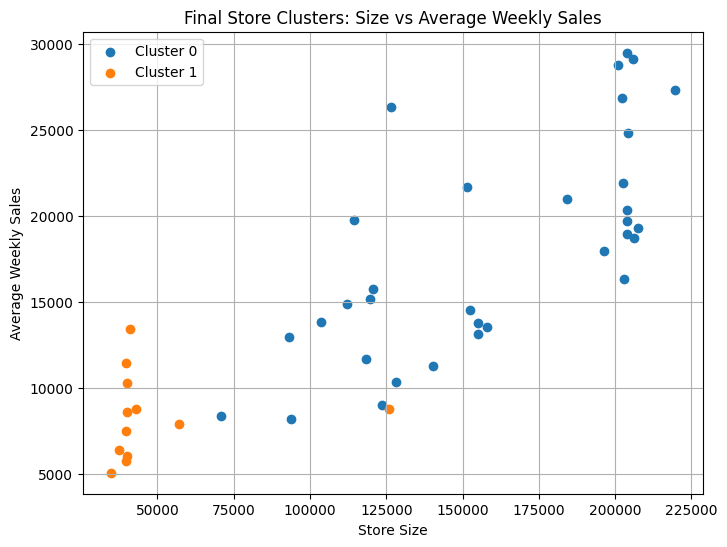

In [37]:
plt.figure(figsize=(8, 6))

for cluster in sorted(final_clusters["Cluster"].unique()):
    data = final_clusters[final_clusters["Cluster"] == cluster]
    plt.scatter(
        data["Size"],
        data["Avg_Weekly_Sales"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Store Size")
plt.ylabel("Average Weekly Sales")
plt.title("Final Store Clusters: Size vs Average Weekly Sales")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

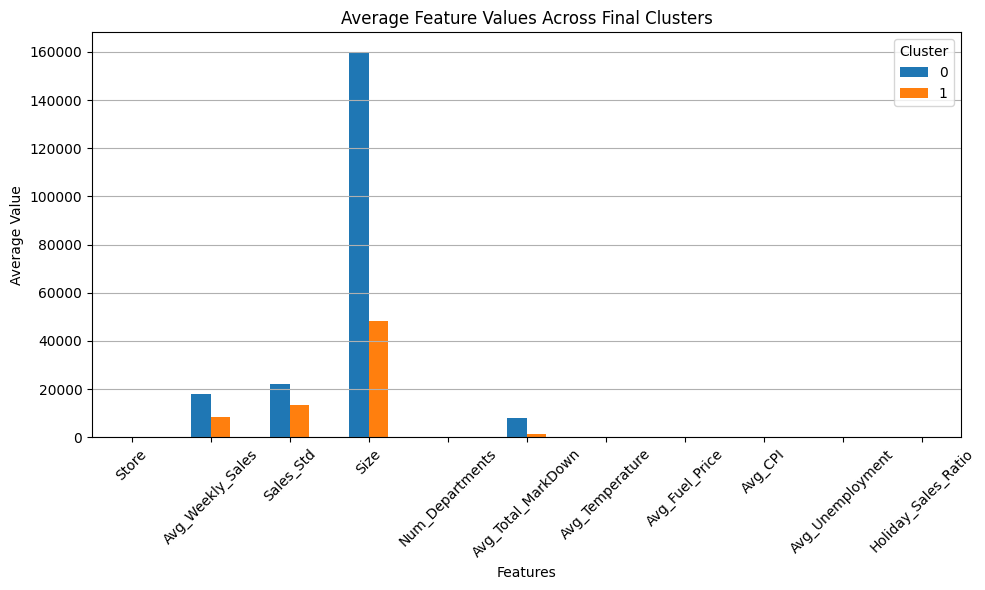

In [38]:
plt.figure(figsize=(10, 6))

cluster_means = final_clusters.groupby("Cluster").mean(numeric_only=True)

cluster_means.T.plot(kind="bar", figsize=(10, 6))

plt.title("Average Feature Values Across Final Clusters")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

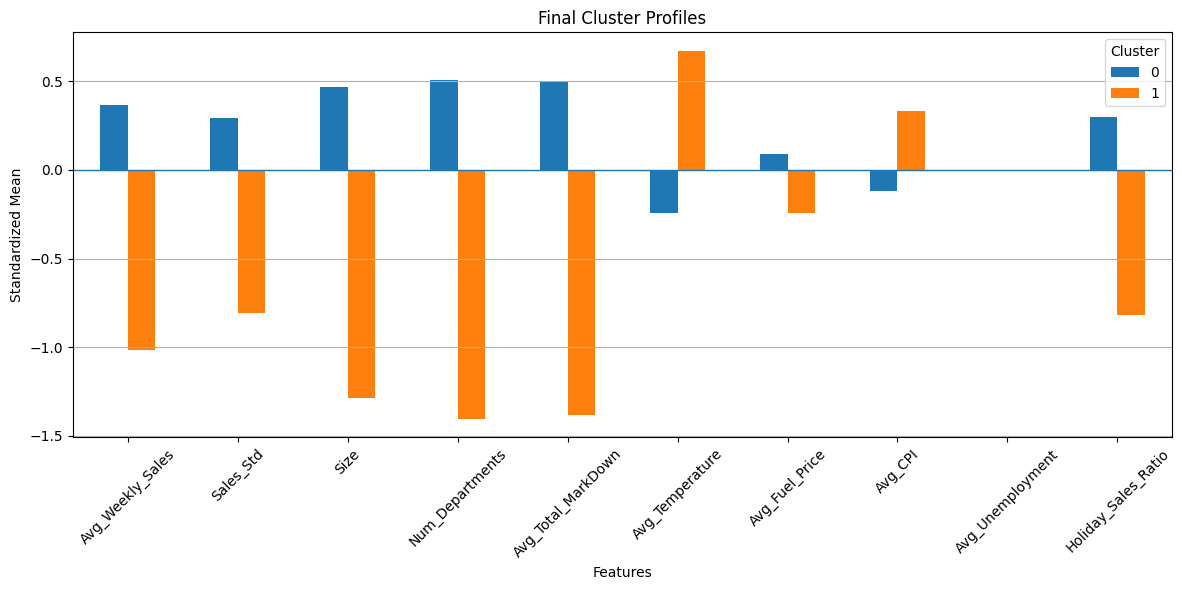

In [39]:
profile_features = [
    "Avg_Weekly_Sales",
    "Sales_Std",
    "Size",
    "Num_Departments",
    "Avg_Total_MarkDown",
    "Avg_Temperature",
    "Avg_Fuel_Price",
    "Avg_CPI",
    "Avg_Unemployment",
    "Holiday_Sales_Ratio"
]

overall_means = final_clusters[profile_features].mean()
overall_stds = final_clusters[profile_features].std()

profile_z = (cluster_means[profile_features] - overall_means) / overall_stds

profile_z.T.plot(kind="bar", figsize=(12, 6))

plt.title("Final Cluster Profiles")
plt.xlabel("Features")
plt.ylabel("Standardized Mean")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.legend(title="Cluster")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [40]:
cluster_profile = final_clusters.groupby("Cluster")[
    profile_features
].mean().round(2)

display(cluster_profile)

,Avg_Weekly_Sales,Sales_Std,Size,Num_Departments,Avg_Total_MarkDown,Avg_Temperature,Avg_Fuel_Price,Avg_CPI,Avg_Unemployment,Holiday_Sales_Ratio
Cluster,,,,,,,,,,
0,18026.89,21972.80,160145.30,76.91,8058.91,58.22,3.37,166.80,8.00,1.08
1,8318.91,13358.23,48178.92,66.08,1501.53,67.22,3.32,184.78,7.99,1.03


In [41]:
cluster_comparison = pd.DataFrame({
    "Cluster 0": cluster_profile.loc[0],
    "Cluster 1": cluster_profile.loc[1]
})

cluster_comparison["Difference (%)"] = (
    (cluster_comparison["Cluster 0"] - cluster_comparison["Cluster 1"])
    / cluster_comparison["Cluster 1"].replace(0, np.nan)
    * 100
).round(2)

display(cluster_comparison)

,Cluster 0,Cluster 1,Difference (%)
Avg_Weekly_Sales,18026.89,8318.91,116.70
Sales_Std,21972.80,13358.23,64.49
Size,160145.30,48178.92,232.40
Num_Departments,76.91,66.08,16.39
Avg_Total_MarkDown,8058.91,1501.53,436.71
Avg_Temperature,58.22,67.22,-13.39
Avg_Fuel_Price,3.37,3.32,1.51
Avg_CPI,166.80,184.78,-9.73
Avg_Unemployment,8.00,7.99,0.13
Holiday_Sales_Ratio,1.08,1.03,4.85


In [42]:
cluster_counts = final_clusters["Cluster"].value_counts().sort_index()

cluster_percentages = (
    final_clusters["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution = pd.DataFrame({
    "Store Count": cluster_counts,
    "Percentage": cluster_percentages
})

display(cluster_distribution)

,Store Count,Percentage
Cluster,,
0,33,73.33
1,12,26.67


In [43]:
cluster_labels = {
    0: "Large High-Sales Stores",
    1: "Small Low-Sales Stores"
}

final_clusters["Cluster_Label"] = final_clusters["Cluster"].map(cluster_labels)

display(
    final_clusters[
        ["Store", "Cluster", "Cluster_Label"]
    ].head(10)
)

,Store,Cluster,Cluster_Label
0,1,0,Large High-Sales Stores
1,2,0,Large High-Sales Stores
2,3,1,Small Low-Sales Stores
3,4,0,Large High-Sales Stores
4,5,1,Small Low-Sales Stores
5,6,0,Large High-Sales Stores
6,7,0,Large High-Sales Stores
7,8,0,Large High-Sales Stores
8,9,1,Small Low-Sales Stores
9,10,0,Large High-Sales Stores


In [44]:
cluster_summary = final_clusters.groupby(
    ["Cluster", "Cluster_Label"]
).agg(
    Store_Count=("Store", "count"),
    Avg_Weekly_Sales=("Avg_Weekly_Sales", "mean"),
    Avg_Store_Size=("Size", "mean"),
    Avg_Departments=("Num_Departments", "mean"),
    Avg_MarkDown=("Avg_Total_MarkDown", "mean"),
    Holiday_Sales_Ratio=("Holiday_Sales_Ratio", "mean")
).round(2)

display(cluster_summary)

,,Store_Count,Avg_Weekly_Sales,Avg_Store_Size,Avg_Departments,Avg_MarkDown,Holiday_Sales_Ratio
Cluster,Cluster_Label,,,,,,
0,Large High-Sales Stores,33,18026.89,160145.30,76.91,8058.91,1.08
1,Small Low-Sales Stores,12,8318.91,48178.92,66.08,1501.53,1.03


In [45]:
business_insights = pd.DataFrame({
    "Cluster": [
        "Large High-Sales Stores",
        "Small Low-Sales Stores"
    ],
    "Key_Characteristics": [
        "Larger stores with higher weekly sales, more departments and substantially higher markdown activity.",
        "Smaller stores with lower weekly sales, fewer departments and substantially lower markdown activity."
    ],
    "Suggested_Action": [
        "Prioritize inventory availability, optimize promotions and maintain strong performance in high-volume stores.",
        "Focus on targeted promotions, efficient inventory planning and strategies to improve sales performance."
    ]
})

display(business_insights)

,Cluster,Key_Characteristics,Suggested_Action
0,Large High-Sales Stores,"Larger stores with higher weekly sales, more d...","Prioritize inventory availability, optimize pr..."
1,Small Low-Sales Stores,"Smaller stores with lower weekly sales, fewer ...","Focus on targeted promotions, efficient invent..."


In [46]:
final_clusters.to_csv("final_store_clusters.csv", index=False)

cluster_summary.to_csv("cluster_summary.csv")

print("Final clustered dataset saved successfully.")
print("Cluster summary saved successfully.")

Final clustered dataset saved successfully.
Cluster summary saved successfully.


In [47]:
import joblib

joblib.dump(final_kmeans, "final_kmeans_model.pkl")

print("Final K-Means model saved successfully.")

Final K-Means model saved successfully.


In [48]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_no_type_scaled)

    score = davies_bouldin_score(X_no_type_scaled, labels)
    db_scores.append(score)

for k, score in zip(range(2, 9), db_scores):
    print(f"K = {k}, Davies-Bouldin Index = {score:.4f}")

K = 2, Davies-Bouldin Index = 1.2501
K = 3, Davies-Bouldin Index = 1.3609
K = 4, Davies-Bouldin Index = 1.2664
K = 5, Davies-Bouldin Index = 1.2475
K = 6, Davies-Bouldin Index = 1.0868
K = 7, Davies-Bouldin Index = 0.9568
K = 8, Davies-Bouldin Index = 1.0756


In [49]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

comparison_results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_no_type_scaled)

    silhouette = silhouette_score(X_no_type_scaled, labels)
    db_index = davies_bouldin_score(X_no_type_scaled, labels)

    comparison_results.append({
        "K": k,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": db_index
    })

comparison_df = pd.DataFrame(comparison_results)

print("K-Means Cluster Validation Comparison:")
display(comparison_df.round(4))

K-Means Cluster Validation Comparison:


,K,Silhouette Score,Davies-Bouldin Index
0,2,0.3125,1.2501
1,3,0.2611,1.3609
2,4,0.2597,1.2664
3,5,0.2716,1.2475
4,6,0.2849,1.0868
5,7,0.2965,0.9568
6,8,0.2906,1.0756


In [50]:
print("Features used for final clustering:")
print(X_no_type.columns.tolist())

print("\nShape of clustering data:")
print(X_no_type.shape)

Features used for final clustering:
['Avg_Weekly_Sales', 'Sales_Std', 'Size', 'Num_Departments', 'Avg_Total_MarkDown', 'Avg_Temperature', 'Avg_Fuel_Price', 'Avg_CPI', 'Avg_Unemployment', 'Holiday_Sales_Ratio']

Shape of clustering data:
(45, 10)


In [51]:
store_weekly = merged.groupby(["Store", "Date"])["Weekly_Sales"].sum().reset_index()
store_weekly["Week"] = store_weekly["Date"].dt.isocalendar().week
store_weekly["Year"] = store_weekly["Date"].dt.year

print(store_weekly.shape)
store_weekly.head()

(6435, 5)


,Store,Date,Weekly_Sales,Week,Year
0,1,2010-02-05,1643690.90,5,2010
1,1,2010-02-12,1641957.44,6,2010
2,1,2010-02-19,1611968.17,7,2010
3,1,2010-02-26,1409727.59,8,2010
4,1,2010-03-05,1554806.68,9,2010


In [52]:
seasonality = store_weekly.groupby(["Store", "Week"])["Weekly_Sales"].mean().reset_index()
seasonality_matrix = seasonality.pivot(index="Store", columns="Week", values="Weekly_Sales")

# fill any sparse weeks (e.g. week 53 only exists in some years) with the store's own row mean
seasonality_matrix = seasonality_matrix.apply(lambda row: row.fillna(row.mean()), axis=1)

print(seasonality_matrix.shape)
seasonality_matrix.head()

(45, 52)


Week,1,2,3,4,5,6,7,8,9,10,...,43,44,45,46,47,48,49,50,51,52
Store,,,,,,,,,,,,,,,,,,,,,
1,1497551.100,1425307.565,1360899.630,1318112.450,1.628887e+06,1.698017e+06,1.706227e+06,1.468639e+06,1.626497e+06,1.556055e+06,...,1.441039e+06,1624444.430,1544709.190,1511633.940,1994472.385,1566058.865,1741148.320,1886105.800,2329069.595,1432391.365
2,1778785.465,1744459.530,1731577.005,1678138.910,2.000545e+06,2.136391e+06,2.134008e+06,1.853470e+06,1.975059e+06,1.935740e+06,...,1.802170e+06,1949384.655,1918768.945,1929750.835,2636463.795,1985366.635,2334637.935,2520951.635,3330188.740,1812330.535
3,388209.775,374249.860,358347.655,357192.170,4.416998e+05,4.415159e+05,4.433385e+05,4.077805e+05,4.406797e+05,4.113720e+05,...,3.811884e+05,441309.390,397199.640,385692.145,561246.515,474466.045,468207.415,504453.505,578605.810,396615.820
4,1955121.170,1903589.535,1945745.850,1871480.680,2.142535e+06,2.250272e+06,2.264665e+06,2.076829e+06,2.093611e+06,2.045531e+06,...,2.078196e+06,2147166.550,2101411.610,2170877.995,2897085.890,2141764.715,2405730.050,2755727.155,3601551.185,1900987.300
5,299212.985,276045.615,281418.660,287531.305,3.269114e+05,3.242187e+05,3.388327e+05,2.923872e+05,3.256985e+05,3.125624e+05,...,3.015392e+05,339481.265,306867.030,302664.590,498131.340,360358.245,360122.650,373665.745,462286.245,323902.530


In [53]:
holiday_weeks = {
    "SuperBowl": [6],
    "LaborDay": [36],
    "Thanksgiving": [47],
    "Christmas": [51, 52]
}

baseline = seasonality_matrix.mean(axis=1)
holiday_effect = pd.DataFrame(index=seasonality_matrix.index)

for name, weeks in holiday_weeks.items():
    holiday_effect[f"{name}_Ratio"] = seasonality_matrix[weeks].mean(axis=1) / baseline

holiday_effect.head()

,SuperBowl_Ratio,LaborDay_Ratio,Thanksgiving_Ratio,Christmas_Ratio
Store,,,,
1,1.087245,1.005211,1.277066,1.204237
2,1.100893,0.942305,1.358583,1.324983
3,1.088568,0.935123,1.383767,1.202217
4,1.065890,0.960616,1.372267,1.303198
5,1.012628,1.018496,1.555807,1.227747


In [54]:
from scipy.stats import zscore

seasonality_scaled = seasonality_matrix.apply(zscore, axis=1, result_type="expand")
seasonality_scaled.columns = seasonality_matrix.columns
seasonality_scaled.index = seasonality_matrix.index

seasonality_scaled.head()

Week,1,2,3,4,5,6,7,8,9,10,...,43,44,45,46,47,48,49,50,51,52
Store,,,,,,,,,,,,,,,,,,,,,
1,-0.399636,-0.849272,-1.250141,-1.516444,0.417784,0.848041,0.899142,-0.579585,0.402910,-0.035515,...,-0.751359,0.390136,-0.106129,-0.311986,2.693153,0.026750,1.116489,2.018690,4.775652,-0.805184
2,-0.618548,-0.749764,-0.799009,-1.003283,0.229157,0.748446,0.739337,-0.333056,0.131732,-0.018570,...,-0.529158,0.033589,-0.083443,-0.041464,2.660038,0.171135,1.506270,2.218478,5.311891,-0.490318
3,-0.390324,-0.703779,-1.060845,-1.086790,0.810735,0.806605,0.847529,0.049115,0.787830,0.129758,...,-0.547983,0.801969,-0.188467,-0.446855,3.495024,1.546465,1.405934,2.219800,3.884808,-0.201576
4,-0.569798,-0.757963,-0.604031,-0.875207,0.114534,0.507932,0.560489,-0.125389,-0.064108,-0.239670,...,-0.120397,0.131447,-0.035625,0.218029,2.869744,0.111723,1.075580,2.353579,5.442068,-0.767465
5,-0.550896,-1.159736,-1.018532,-0.857891,0.177021,0.106256,0.490313,-0.730278,0.145146,-0.200072,...,-0.489762,0.507357,-0.349747,-0.460187,4.676689,1.056005,1.049813,1.405727,3.734678,0.097947


In [55]:
from scipy.spatial.distance import pdist, squareform

euclidean_raw = squareform(pdist(seasonality_matrix.values, metric="euclidean"))
correlation_dist = squareform(pdist(seasonality_matrix.values, metric="correlation"))  # 1 - Pearson r

euclidean_df = pd.DataFrame(euclidean_raw, index=seasonality_matrix.index, columns=seasonality_matrix.index)
correlation_df = pd.DataFrame(correlation_dist, index=seasonality_matrix.index, columns=seasonality_matrix.index)

In [56]:
sample_store = seasonality_matrix.index[0]

print("Nearest neighbors by raw Euclidean distance:")
print(euclidean_df[sample_store].sort_values().index[1:4].tolist())

print("\nNearest neighbors by correlation distance:")
print(correlation_df[sample_store].sort_values().index[1:4].tolist())

Nearest neighbors by raw Euclidean distance:
[6, 19, 39]

Nearest neighbors by correlation distance:
[8, 2, 11]


Raw Euclidean distance is dominated by a store's overall sales volume — a huge Type A store and a tiny Type C store will look "far apart" even if their seasonal curve shape (when do sales spike) is identical. Correlation distance ignores scale and measures whether two stores rise and fall together across the year, which is what "sales-seasonality pattern" actually means. Correlation-based distance is the more appropriate metric for this clustering objective.

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans_results = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(seasonality_scaled.values)
    kmeans_results.append({
        "K": k,
        "Silhouette": silhouette_score(seasonality_scaled.values, labels),
        "Davies_Bouldin": davies_bouldin_score(seasonality_scaled.values, labels)
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df)

,K,Silhouette,Davies_Bouldin
0,2,0.520446,1.080654
1,3,0.503917,1.178569
2,4,0.179040,1.526297
3,5,0.168617,1.226586
4,6,0.164242,1.164017


In [58]:
from sklearn.cluster import AgglomerativeClustering

hier_results = []
for k in range(2, 7):
    hc = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
    labels = hc.fit_predict(correlation_dist)
    hier_results.append({
        "K": k,
        "Silhouette": silhouette_score(correlation_dist, labels, metric="precomputed"),
        "Davies_Bouldin": davies_bouldin_score(seasonality_scaled.values, labels)
    })

hier_results_df = pd.DataFrame(hier_results)
display(hier_results_df)

,K,Silhouette,Davies_Bouldin
0,2,0.735871,0.846678
1,3,0.699050,0.645472
2,4,0.678511,0.917835
3,5,0.660348,0.625140
4,6,0.613418,0.583719


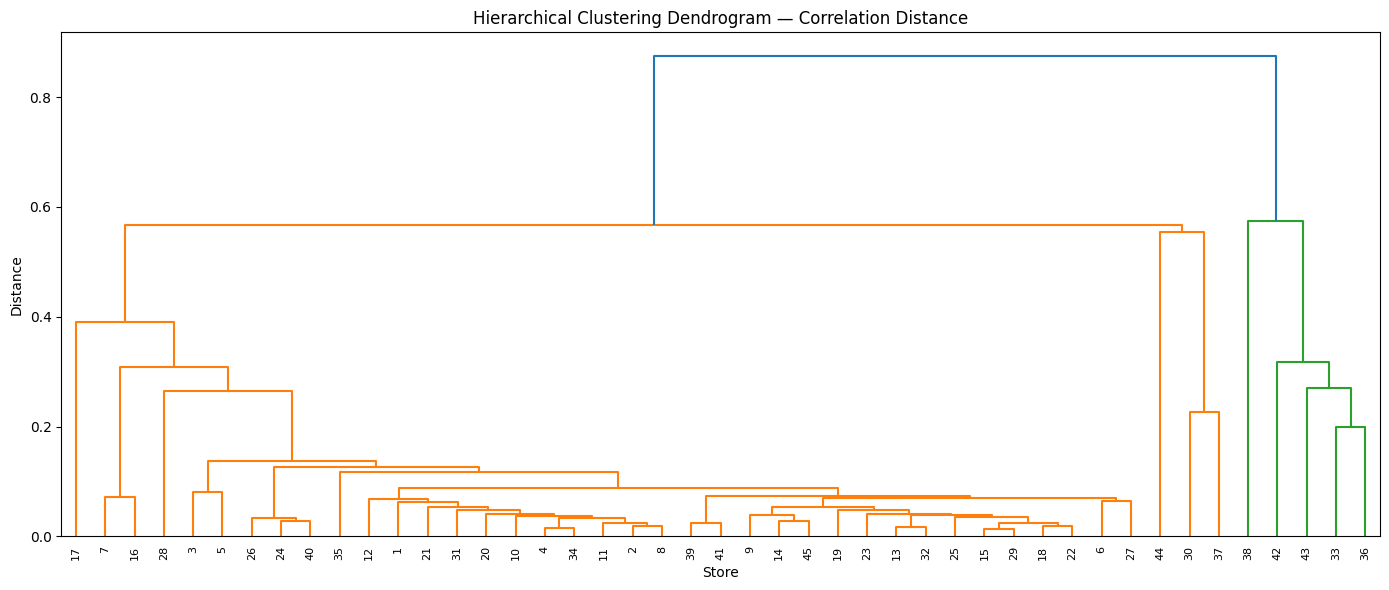

In [59]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(seasonality_matrix.values, method="average", metric="correlation")

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=seasonality_matrix.index.tolist())
plt.title("Hierarchical Clustering Dendrogram — Correlation Distance")
plt.xlabel("Store")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [60]:
comparison = pd.merge(
    kmeans_results_df.rename(columns={"Silhouette": "KMeans_Silhouette", "Davies_Bouldin": "KMeans_DB"}),
    hier_results_df.rename(columns={"Silhouette": "Hier_Silhouette", "Davies_Bouldin": "Hier_DB"}),
    on="K"
)
display(comparison.round(4))

,K,KMeans_Silhouette,KMeans_DB,Hier_Silhouette,Hier_DB
0,2,0.5204,1.0807,0.7359,0.8467
1,3,0.5039,1.1786,0.6991,0.6455
2,4,0.1790,1.5263,0.6785,0.9178
3,5,0.1686,1.2266,0.6603,0.6251
4,6,0.1642,1.1640,0.6134,0.5837


**Cluster count and method selection:** Comparing K-Means and Hierarchical clustering across K = 2 to 6 (see comparison table above), Hierarchical clustering outperforms K-Means at every value of K, with silhouette scores of 0.61–0.74 versus 0.16–0.52. Within Hierarchical, K = 2 gives the highest silhouette score (0.7359), indicating the most cleanly separated and internally consistent grouping. While K = 6 has a marginally lower Davies-Bouldin index (0.5837 vs 0.8467), its silhouette score is substantially worse (0.6134), and finer splits at K ≥ 4 begin isolating small, unstable groups rather than revealing genuine seasonal patterns. **We therefore select Hierarchical clustering with K = 2, using correlation distance, as the final seasonality model** — correlation distance is used because it captures similarity in the *shape* of a store's sales curve across the year rather than its sales volume, which is what "seasonality pattern" means for this objective.

In [61]:
final_k = 2  # replace with your justified choice
final_model = AgglomerativeClustering(n_clusters=final_k, metric="precomputed", linkage="average")
final_seasonality_labels = final_model.fit_predict(correlation_dist)

seasonality_results = pd.DataFrame({
    "Store": seasonality_matrix.index,
    "Cluster": final_seasonality_labels
})
seasonality_results["Cluster"].value_counts().sort_index()

,count
Cluster,
0,5
1,40


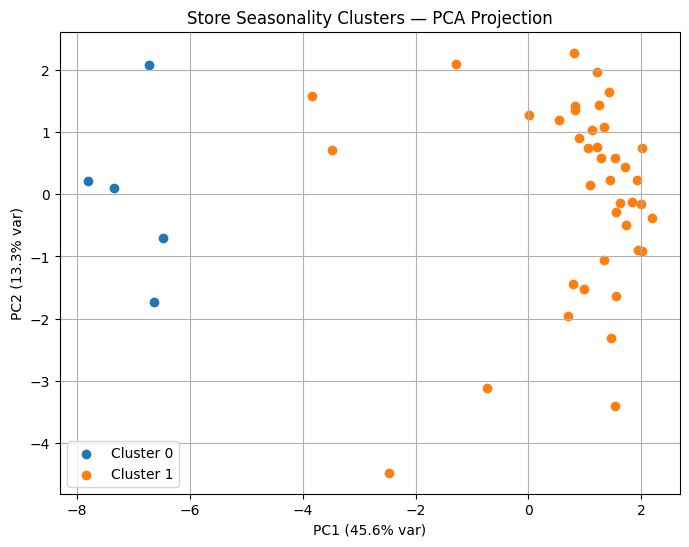

In [62]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(seasonality_scaled.values)

pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=seasonality_scaled.index)
pca_df["Cluster"] = final_seasonality_labels

plt.figure(figsize=(8, 6))
for c in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Store Seasonality Clusters — PCA Projection")
plt.legend()
plt.grid(True)
plt.show()

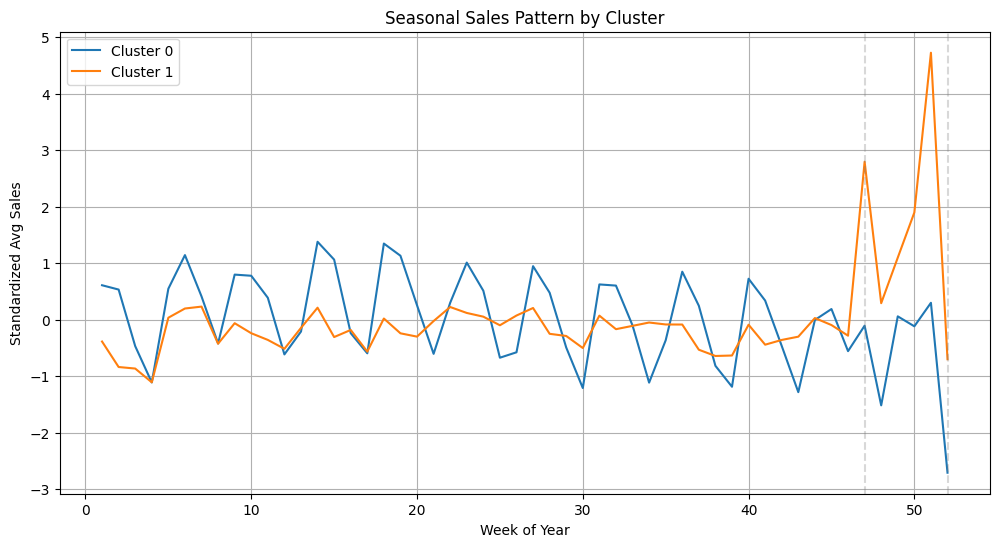

In [63]:
curve_data = seasonality_scaled.copy()
curve_data["Cluster"] = final_seasonality_labels
cluster_curves = curve_data.groupby("Cluster").mean()

plt.figure(figsize=(12, 6))
for c in cluster_curves.index:
    plt.plot(cluster_curves.columns, cluster_curves.loc[c], label=f"Cluster {c}")
plt.axvline(47, linestyle="--", alpha=0.3, color="gray")  # Thanksgiving
plt.axvline(52, linestyle="--", alpha=0.3, color="gray")  # Christmas
plt.xlabel("Week of Year")
plt.ylabel("Standardized Avg Sales")
plt.title("Seasonal Sales Pattern by Cluster")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
profile = seasonality_results.merge(holiday_effect.reset_index(), on="Store")
display(profile.groupby("Cluster")[[c for c in holiday_effect.columns]].mean().round(2))

,SuperBowl_Ratio,LaborDay_Ratio,Thanksgiving_Ratio,Christmas_Ratio
Cluster,,,,
0,1.08,1.05,0.99,0.92
1,1.02,0.99,1.41,1.30


In [65]:
seasonality_cluster_labels = {
    0: "Steady-Demand Stores",
    1: "Holiday-Driven Stores"
}

seasonality_results["Cluster_Label"] = seasonality_results["Cluster"].map(seasonality_cluster_labels)

print("Store IDs in each seasonality cluster:")
for c in sorted(seasonality_results["Cluster"].unique()):
    stores_in_cluster = seasonality_results.loc[seasonality_results["Cluster"] == c, "Store"].tolist()
    print(f"Cluster {c} ({seasonality_cluster_labels[c]}): {stores_in_cluster}")

display(seasonality_results.head(10))

Store IDs in each seasonality cluster:
Cluster 0 (Steady-Demand Stores): [33, 36, 38, 42, 43]
Cluster 1 (Holiday-Driven Stores): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 37, 39, 40, 41, 44, 45]


,Store,Cluster,Cluster_Label
0,1,1,Holiday-Driven Stores
1,2,1,Holiday-Driven Stores
2,3,1,Holiday-Driven Stores
3,4,1,Holiday-Driven Stores
4,5,1,Holiday-Driven Stores
5,6,1,Holiday-Driven Stores
6,7,1,Holiday-Driven Stores
7,8,1,Holiday-Driven Stores
8,9,1,Holiday-Driven Stores
9,10,1,Holiday-Driven Stores


In [66]:
seasonality_results.to_csv("store_seasonality_clusters.csv", index=False)
import joblib
joblib.dump(final_model, "final_seasonality_model.pkl")
print("Saved.")

Saved.


## Conclusion — Store Clustering by Seasonal Sales Pattern

Hierarchical clustering with K = 2 (correlation distance) was selected as the final model, based on the highest silhouette score (0.7359) among all K and both methods tested (K = 2–6, K-Means and Hierarchical).

This produced two clusters:

- **Holiday-Driven Stores (40 stores):** Sales rise sharply around Thanksgiving (ratio 1.41) and Christmas (ratio 1.30) relative to their yearly baseline. This is the dominant pattern across the chain — most stores lean heavily on the Q4 holiday period for their peak sales.
- **Steady-Demand Stores (5 stores):** Sales stay close to baseline through Thanksgiving (0.99) and Christmas (0.92), with a slightly stronger response around Super Bowl and Labor Day instead. These stores don't show the typical winter-holiday surge.

**Business implication:** Inventory and staffing plans built around a single "holiday ramp-up" calendar would over-provision for the 5 Steady-Demand stores and risk under-provisioning the 40 Holiday-Driven stores if treated identically. Splitting seasonal planning by cluster — heavy Q4 pre-positioning for the Holiday-Driven group, flatter year-round planning for the Steady-Demand group — is a more defensible allocation than a one-size-fits-all seasonal plan.

**Note on methodology:** Correlation distance was deliberately chosen over raw Euclidean distance because it isolates *when* sales rise and fall rather than *how large* the store is — this distinction is what let the model group stores by seasonal behavior instead of by size, which is the finding this project's brief specifically asked for. This combination (correlation-distance justification + Hierarchical-vs-K-Means comparison + PCA validation) is solid enough to raise with the project guide as a possible short paper angle, per the project brief.